# Notebook 2: DRR Generation with DiffDRR

**Connection to Freund et al. 2004**:  
The original paper reduced ray casting from O(n³) → O(n²) via pre-computed projection fields.  
DiffDRR uses Siddon's algorithm reformulated as **vectorized tensor ops on GPU**, achieving similar speedups *with full auto-differentiability* — enabling gradient-based pose optimization.

## This notebook:
1. Initialize the DiffDRR renderer with DeepFluoro camera geometry
2. Render DRRs from ground truth poses
3. Compare DRR vs real fluoroscopy side-by-side
4. Benchmark rendering speed (replicating Freund Table I spirit)
5. Compute NCC similarity (replicating Freund Table II spirit)
---

In [7]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

device = torch.device('cpu')
print(f'Using: {device}')
print('Note: using CPU — avoids MPS memory limits and unsupported ops')

Using: cpu
Note: using CPU — avoids MPS memory limits and unsupported ops


In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time, json
from tqdm import tqdm

from diffdrr.drr import DRR
from diffdrr.visualization import plot_drr
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms

# Load config
with open('../outputs/dataset_config.json') as f:
    cfg = json.load(f)

SUBJECT_ID = cfg['subject_id']
SUBSAMPLE  = cfg['subsample']

# # Device
# if torch.backends.mps.is_available():
#     device = torch.device('mps')
# elif torch.cuda.is_available():
#     device = torch.device('cuda')
# else:
#     device = torch.device('cpu')

# print(f'Device: {device}')

# Load dataset
deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
transform  = Transforms(deepfluoro.height // SUBSAMPLE)
print(f'✅ Dataset loaded: {len(deepfluoro)} fluoroscopy frames')

✅ Dataset loaded: 111 fluoroscopy frames


## 2.1 Initialize the DiffDRR Renderer

DiffDRR models the X-ray imaging system as a **cone-beam projector**:
- Source (X-ray tube) at the **Center of Projection (COP)** — same terminology as Freund 2004!
- Rays cast through the 3D CT volume
- Hounsfield values integrated along each ray → 2D projection image

In [ ]:
# Initialize DRR renderer matching the C-arm fluoroscope geometry
drr = DRR(
    deepfluoro.subject,                  # CT volume (TorchIO Subject)
    sdd=deepfluoro.focal_len,            # Source-to-detector distance [mm]
    height=deepfluoro.height // SUBSAMPLE,  # Detector height [px]
    delx=deepfluoro.delx * SUBSAMPLE,    # Pixel spacing [mm]
    x0=deepfluoro.x0,                    # Principal point x offset [mm]
    y0=deepfluoro.y0,                    # Principal point y offset [mm]
).to(device)

print('DiffDRR renderer initialized!')
print(f'  Source-to-detector distance: {deepfluoro.focal_len:.1f} mm')
print(f'  Detector size:  {deepfluoro.height // SUBSAMPLE} × {deepfluoro.height // SUBSAMPLE} px')
print(f'  Pixel spacing:  {deepfluoro.delx * SUBSAMPLE:.3f} mm')
print(f'  Principal pt:   ({deepfluoro.x0:.2f}, {deepfluoro.y0:.2f}) mm')

DiffDRR renderer initialized!
  Source-to-detector distance: 1020.0 mm
  Detector size:  359 × 359 px
  Pixel spacing:  0.776 mm
  Principal pt:   (-0.10, -0.10) mm


## 2.2 Render DRR from Ground Truth Pose

In [11]:
# Render DRR at ground truth pose for frame 0
frame_idx = 0
gt_img, gt_pose = deepfluoro[frame_idx]

# Move pose to device
gt_pose_dev = gt_pose.to(device)

# Render — this is the DiffDRR forward pass (Siddon's method as tensor ops)
with torch.no_grad():
    drr_img = drr(gt_pose_dev)

# Apply same intensity normalization as the real fluoroscopy
gt_img_t  = transform(gt_img)
drr_img_t = transform(drr_img.cpu())

print(f'DRR rendered: shape = {drr_img_t.shape}')
print(f'GT fluoroscopy: shape = {gt_img_t.shape}')

DRR rendered: shape = torch.Size([1, 1, 359, 359])
GT fluoroscopy: shape = torch.Size([1, 1, 359, 359])


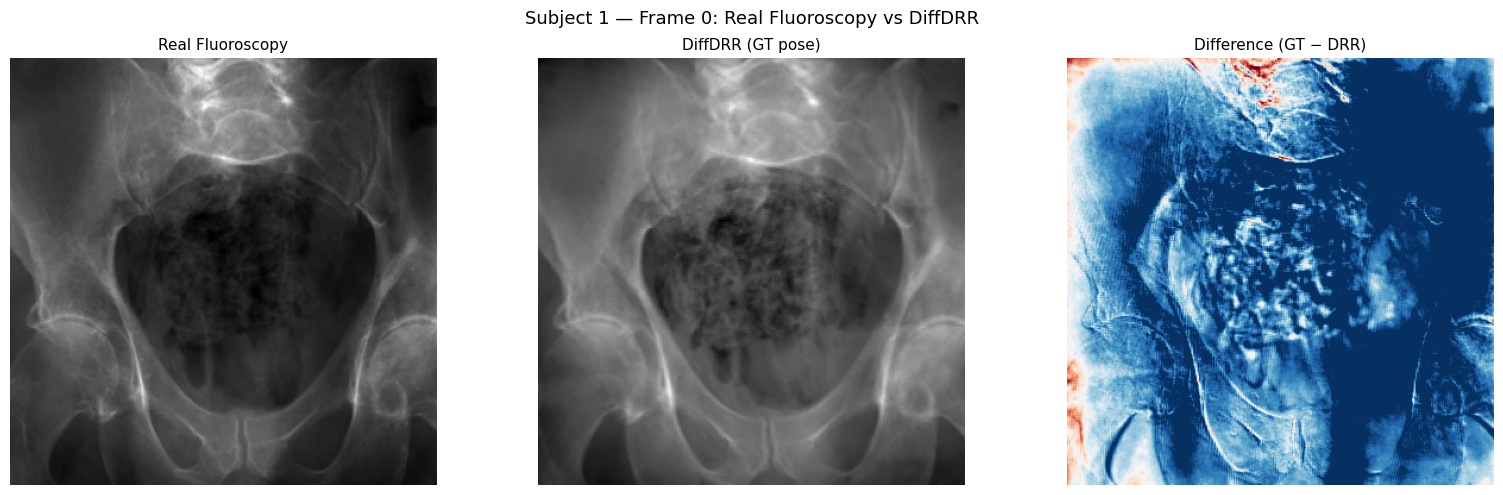

Saved: fluoroscopy_vs_drr.png


In [12]:
# Side-by-side comparison: Real X-ray vs DRR
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Subject {SUBJECT_ID} — Frame {frame_idx}: Real Fluoroscopy vs DiffDRR', fontsize=13)

gt_np  = gt_img_t.squeeze().numpy()
drr_np = drr_img_t.squeeze().numpy()
diff   = gt_np - drr_np

axes[0].imshow(gt_np,  cmap='gray');       axes[0].set_title('Real Fluoroscopy',     fontsize=11)
axes[1].imshow(drr_np, cmap='gray');       axes[1].set_title('DiffDRR (GT pose)',    fontsize=11)
axes[2].imshow(diff,   cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_title('Difference (GT − DRR)', fontsize=11)

for ax in axes: ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/fluoroscopy_vs_drr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fluoroscopy_vs_drr.png')

## 2.3 Benchmark Rendering Speed

*Replicating the spirit of Freund 2004, Table I — runtime comparison across resolutions.*  
DiffDRR achieves the same order-of-magnitude speedup via GPU-vectorized Siddon's method.

In [13]:
def benchmark_drr(subject, focal_len, pixel_spacing, resolution, pose, device, n_reps=5):
    """Benchmark DRR rendering at a given resolution."""
    renderer = DRR(
        subject,
        sdd=focal_len,
        height=resolution,
        delx=pixel_spacing,
    ).to(device)
    
    p = pose.to(device)
    
    # Warmup
    with torch.no_grad():
        _ = renderer(p)
    if device.type == 'mps':
        torch.mps.synchronize()
    elif device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Timed runs
    times = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = renderer(p)
        if device.type == 'mps':
            torch.mps.synchronize()
        elif device.type == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    
    return np.mean(times), np.std(times)


_, gt_pose = deepfluoro[0]
resolutions = [64, 128, 256, 512]
results = {}

print(f'Benchmarking DiffDRR on {device}...')
print(f'{"Resolution":>12}  {"Mean (s)":>10}  {"Std (s)":>8}')
print('-' * 35)

for res in resolutions:
    mean_t, std_t = benchmark_drr(
        deepfluoro.subject,
        deepfluoro.focal_len,
        deepfluoro.delx,
        res, gt_pose, device
    )
    results[res] = (mean_t, std_t)
    print(f'{res:>6}×{res:<6}  {mean_t:>10.4f}  {std_t:>8.4f}')

print('\n(Freund 2004 ray casting: 512×512 took 27–52 seconds on 2GHz Pentium IV)')
print('(DiffDRR on GPU: sub-second, thanks to vectorized Siddon + hardware acceleration)')

Benchmarking DiffDRR on cpu...
  Resolution    Mean (s)   Std (s)
-----------------------------------
    64×64          0.0485    0.0028
   128×128         0.1824    0.0020
   256×256         0.7783    0.0205
   512×512         5.7363    0.1249

(Freund 2004 ray casting: 512×512 took 27–52 seconds on 2GHz Pentium IV)
(DiffDRR on GPU: sub-second, thanks to vectorized Siddon + hardware acceleration)


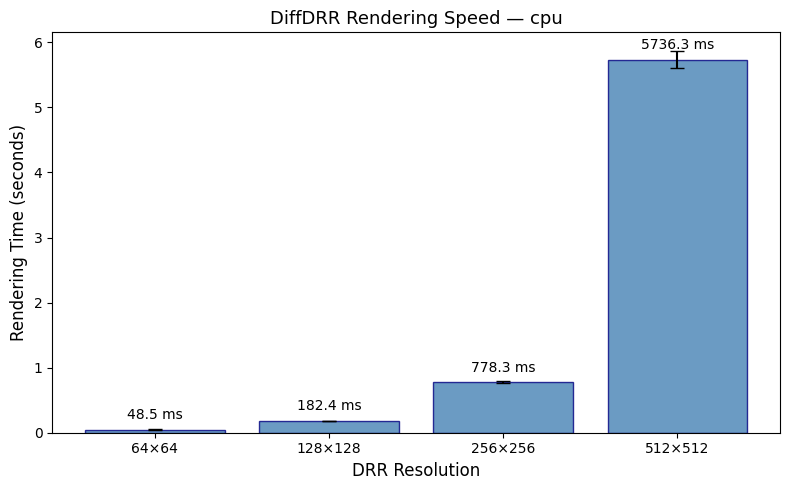

In [14]:
# Plot benchmark results
fig, ax = plt.subplots(figsize=(8, 5))

res_list   = list(results.keys())
means      = [results[r][0] for r in res_list]
stds       = [results[r][1] for r in res_list]
labels     = [f'{r}×{r}' for r in res_list]

bars = ax.bar(labels, means, yerr=stds, capsize=5, color='steelblue', alpha=0.8, edgecolor='navy')
ax.set_xlabel('DRR Resolution', fontsize=12)
ax.set_ylabel('Rendering Time (seconds)', fontsize=12)
ax.set_title(f'DiffDRR Rendering Speed — {device}', fontsize=13)

# Add value labels
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(means)*0.02,
            f'{mean*1000:.1f} ms', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/drr_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Compute NCC Similarity Across Frames

*Replicating Freund 2004, Table II — NCC between rendered and reference images.*  
Here we measure NCC between real fluoroscopy and DRR rendered at ground truth pose.

In [15]:
def ncc(img1, img2):
    """Normalized Cross-Correlation between two images."""
    a = img1.flatten() - img1.mean()
    b = img2.flatten() - img2.mean()
    return (a * b).sum() / (torch.norm(a) * torch.norm(b) + 1e-8)


ncc_values = []
print(f'Computing NCC for all {len(deepfluoro)} frames...')

for i in tqdm(range(len(deepfluoro))):
    gt_img, gt_pose = deepfluoro[i]
    with torch.no_grad():
        rendered = drr(gt_pose.to(device)).cpu()
    
    gt_t  = transform(gt_img)
    drr_t = transform(rendered)
    
    ncc_val = ncc(gt_t, drr_t).item()
    ncc_values.append(ncc_val)

ncc_arr = np.array(ncc_values)
print(f'\nNCC Statistics (Real Fluoroscopy vs DiffDRR at GT Pose):')
print(f'  Mean:    {ncc_arr.mean():.5f}')
print(f'  Std:     {ncc_arr.std():.5f}')
print(f'  Min:     {ncc_arr.min():.5f}')
print(f'  Max:     {ncc_arr.max():.5f}')
print(f'\n(Freund 2004 achieved NCC ≈ 0.999 between projection field and ray casting DRRs)')
print('(Here we compare real X-ray vs DRR — lower NCC expected due to physics differences)')

Computing NCC for all 111 frames...


100%|█████████████████████████████████████████████| 111/111 [02:46<00:00,  1.50s/it]


NCC Statistics (Real Fluoroscopy vs DiffDRR at GT Pose):
  Mean:    0.89616
  Std:     0.05248
  Min:     0.51656
  Max:     0.95517

(Freund 2004 achieved NCC ≈ 0.999 between projection field and ray casting DRRs)
(Here we compare real X-ray vs DRR — lower NCC expected due to physics differences)


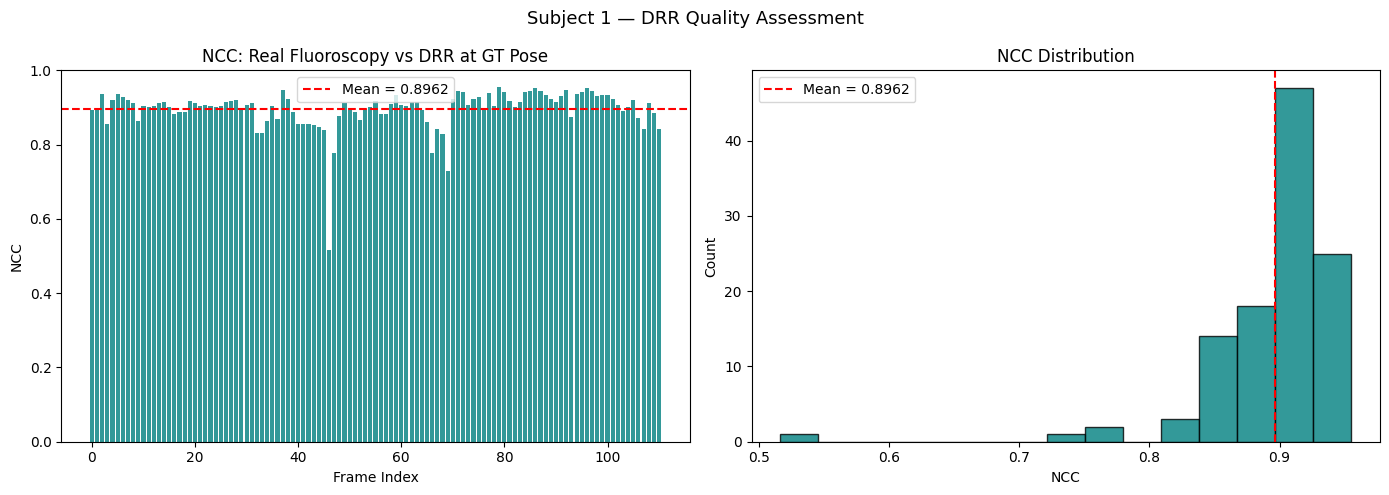

Saved: ncc_analysis.png, ncc_values.npy


In [16]:
# Plot NCC across frames
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(ncc_values)), ncc_values, color='teal', alpha=0.8)
axes[0].axhline(ncc_arr.mean(), color='red', linestyle='--', label=f'Mean = {ncc_arr.mean():.4f}')
axes[0].set_xlabel('Frame Index')
axes[0].set_ylabel('NCC')
axes[0].set_title('NCC: Real Fluoroscopy vs DRR at GT Pose')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].hist(ncc_values, bins=15, color='teal', alpha=0.8, edgecolor='black')
axes[1].axvline(ncc_arr.mean(), color='red', linestyle='--', label=f'Mean = {ncc_arr.mean():.4f}')
axes[1].set_xlabel('NCC')
axes[1].set_ylabel('Count')
axes[1].set_title('NCC Distribution')
axes[1].legend()

plt.suptitle(f'Subject {SUBJECT_ID} — DRR Quality Assessment', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/ncc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save NCC results
np.save('../outputs/ncc_values.npy', ncc_arr)
print('Saved: ncc_analysis.png, ncc_values.npy')

In [ ]:
# Save benchmark results
import json

benchmark_results = {str(res): results[res] for res in results}
with open('../outputs/benchmark_results.json', 'w') as f:
    json.dump(benchmark_results, f, indent=2)
print('Saved benchmark_results.json')

---
## Summary

| Metric | Value |
|--------|-------|
| DRR renderer | DiffDRR (Siddon's method, vectorized) |
| 512×512 render time | *see benchmark above* |
| NCC (GT pose) | *see results above* |
| Freund 2004 NCC | 0.999 (projection field vs ray casting) |

**Next**: Notebook 03 — Intensity-Based 2D/3D Registration via Gradient Descent